# 📆  Import des librairies

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from haversine import haversine

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set(style="whitegrid")

# 📂  Chargement et affichage des données


In [2]:
file_path = "2016_building_energy_benchmarking.csv"
data = pd.read_csv(file_path)
print(f"Shape initiale : {data.shape}")
data.head()


Shape initiale : (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [3]:
#affichage des colonnes cibles 
data[['TotalGHGEmissions','SiteEnergyUse(kBtu)']].describe()


,TotalGHGEmissions,SiteEnergyUse(kBtu)
count,3367.000000,3.371000e+03
mean,119.723971,5.403667e+06
std,538.832227,2.161063e+07
min,-0.800000,0.000000e+00
25%,9.495000,9.251286e+05
50%,33.920000,1.803753e+06
75%,93.940000,4.222455e+06
max,16870.980000,8.739237e+08


# 🔄 Gestion des doublons

In [4]:
print(f"Doublons : {data.duplicated().sum()}")


Doublons : 0


# 🔎 Nettoyage des types et conversion




In [5]:
cols_to_numeric = ["SiteEnergyUse(kBtu)", "TotalGHGEmissions", "ENERGYSTARScore"]
for col in cols_to_numeric:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

In [6]:
# Conversion des dates 
if 'DataYear' in data.columns:
    data['DataYear'] = pd.to_numeric(data['DataYear'], errors='coerce')


# 🏠  Filtrage : On enlève les bâtiments résidentiels


In [7]:
if 'BuildingType' in data.columns:
    data = data[~data['BuildingType'].str.contains("Multifamily", na=False)]


# 🔢 Traitement des valeurs manquantes


<AxesSubplot:>

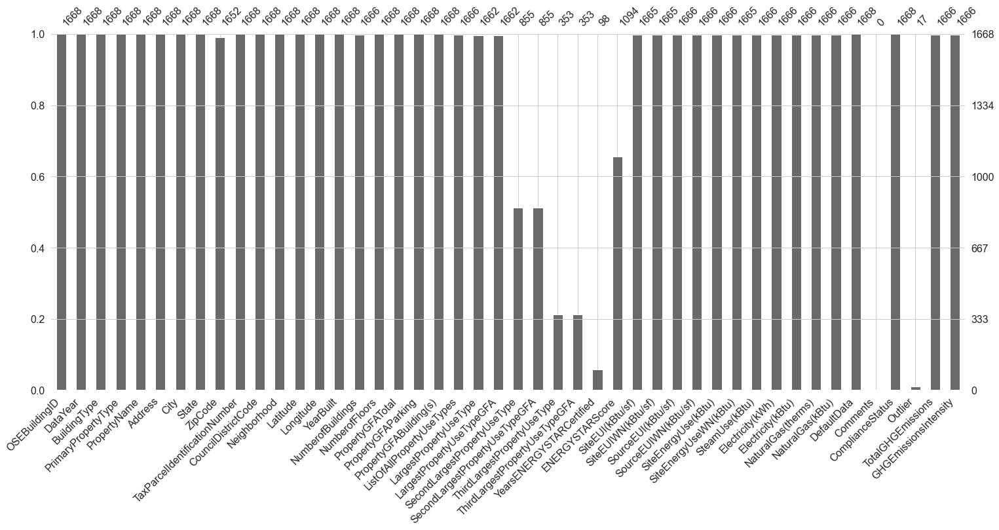

In [8]:
import missingno as msno

msno.bar(data)

In [9]:
def get_numbers_missing(df):
    nb_nan_tot = df.isna().sum().sum()
    nb_donnees_tot = np.product(df.shape)
    percent_nan_tot = round((nb_nan_tot / nb_donnees_tot) * 100, 2)
    print(f'Il y a {nb_nan_tot} de valeurs manquantes (NaN) pour un total de {nb_donnees_tot} données soit ({percent_nan_tot} %)')


def table_numbers_missing(df):
    values = df.isnull().sum()
    percentage = round(100 * (values / len(df)),2)
    
    table = pd.concat([values, percentage.round(2)], axis=1)
    table.columns = ['Nombres_de_valeurs_manquantes','Proportion_de_valeurs_manquantes_%']
    display(table[table['Nombres_de_valeurs_manquantes'] != 0]
                .sort_values('Proportion_de_valeurs_manquantes_%', ascending=False))


In [10]:
get_numbers_missing(data)

Il y a 9780 de valeurs manquantes (NaN) pour un total de 76728 données soit (12.75 %)


In [11]:
table_numbers_missing(data)

,Nombres_de_valeurs_manquantes,Proportion_de_valeurs_manquantes_%
Comments,1668,100.00
Outlier,1651,98.98
YearsENERGYSTARCertified,1570,94.12
ThirdLargestPropertyUseTypeGFA,1315,78.84
ThirdLargestPropertyUseType,1315,78.84
SecondLargestPropertyUseType,813,48.74
SecondLargestPropertyUseTypeGFA,813,48.74
ENERGYSTARScore,574,34.41
ZipCode,16,0.96
LargestPropertyUseTypeGFA,6,0.36


In [12]:

# Suppression des colonnes avec trop de NA ou inutiles
threshold = 0.4  # On garde si moins de 40% de valeurs manquantes (pour qu'on puisse garder ENERGYSTARSCORE)
valid_cols = data.columns[data.isnull().mean() < threshold]
data = data[valid_cols]


In [13]:
# Calcul du pourcentage de valeurs manquantes pour les colonnes essentielles
cols_essentielles = ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]
missing_values = data[cols_essentielles].isna().mean() * 100

# Affichage du pourcentage de valeurs manquantes
print(missing_values)

SiteEnergyUse(kBtu)    0.119904
TotalGHGEmissions      0.119904
dtype: float64


In [14]:
# Suppression des lignes NA pour les cibles et variables clés puisque le taux de 12% est faible, donc la suppression n'aura presque aucun impact sur notre analyse
data.dropna(subset=cols_essentielles, inplace=True)




In [15]:
data.head(5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


>complianceStatus : Si une propriété satisfait les exigences d'analyse comparative énergétique pour l'année de déclaration en cours. 92% des données correspondent, il n'y pas d'intérêt à conserver cette variable.


>DefaultData : si un batiment a au moins une valeur par défault dans ses relevés. Il y a 94% de produits qui n'ont pas de valeurs par défault. La quasi totalité des données, donc nous pouvons supprimer la variable.

>L'étude se fait sur une ville et donc un seul Etat. Les variables State et City sont donc inutiles.

>Afin de localiser les bâtiments la Longitude et la Latitude seront les données utilisées. On supprime donc l'adresse et le ZipCode.

>CouncilDistrictCode district du bâtiment.La consommation en énergie d'un bâtiment ne peut pas dépendre de son district.


In [16]:
data.drop(columns = ["DataYear","DefaultData","State",
                     "City", "ComplianceStatus",
                     "ZipCode","Address",
                     "CouncilDistrictCode"], inplace = True)


# 🚩 Suppression des outliers


C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


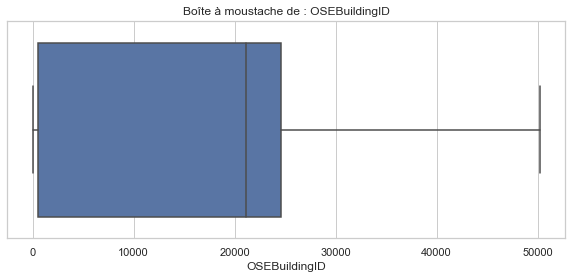

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


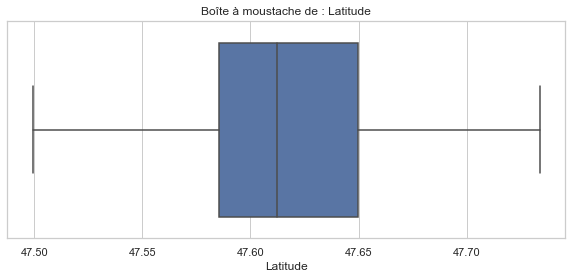

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


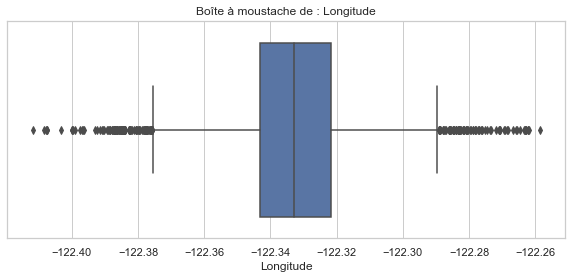

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


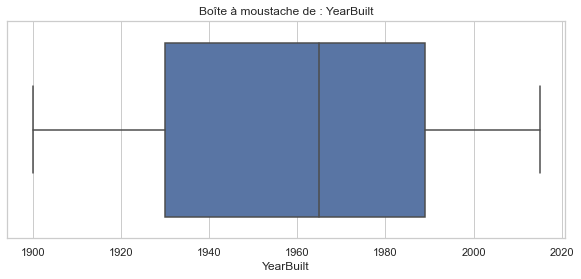

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


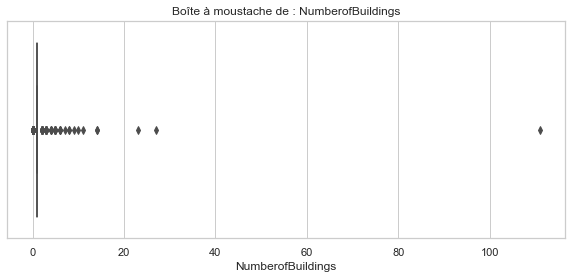

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


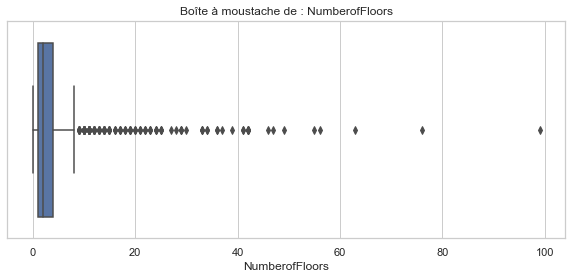

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


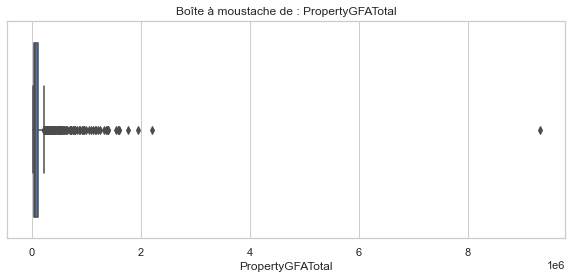

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


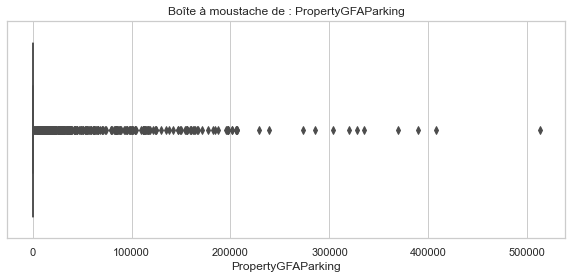

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


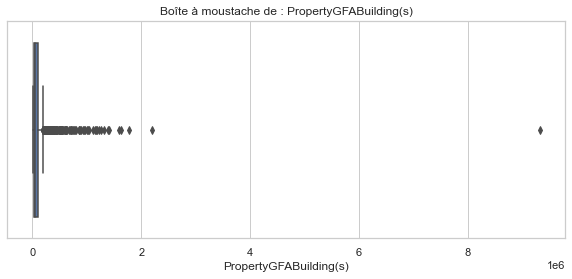

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


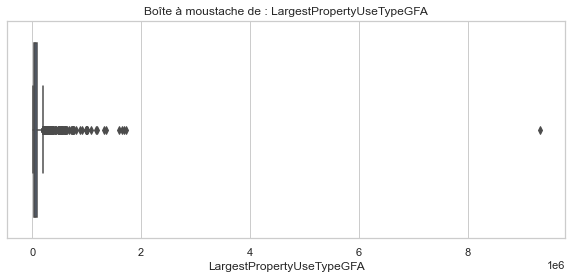

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


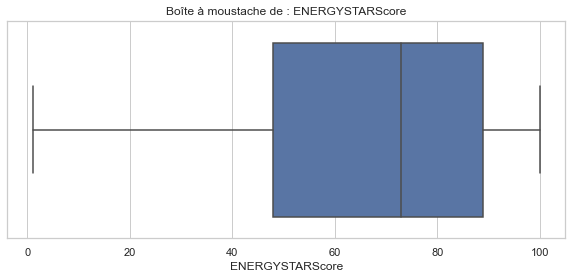

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


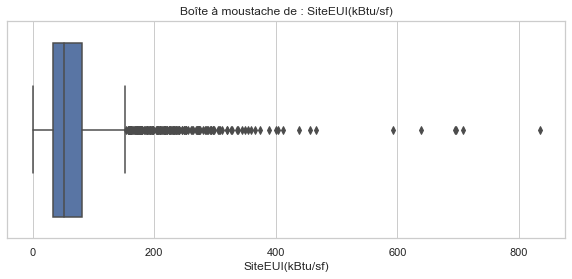

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


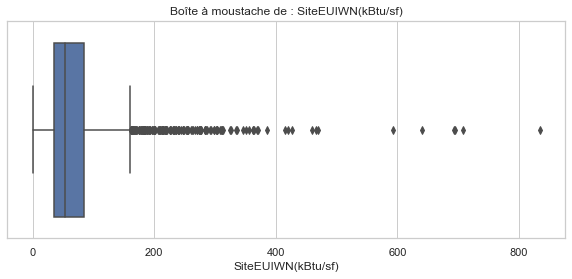

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


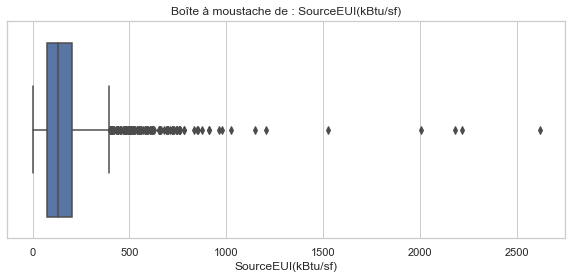

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


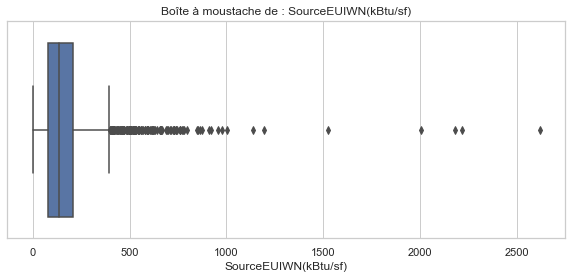

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


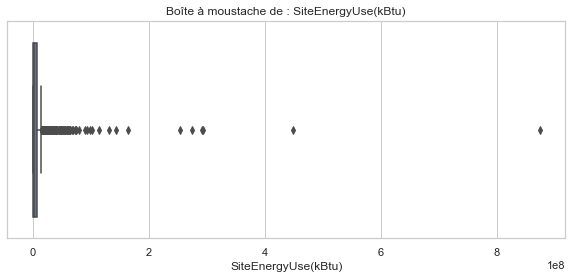

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


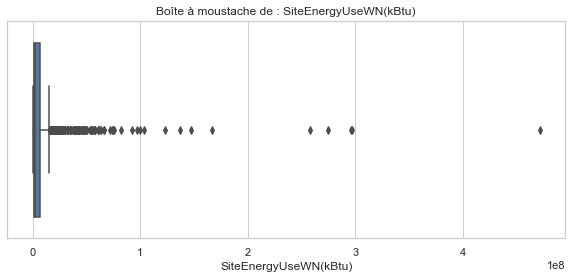

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


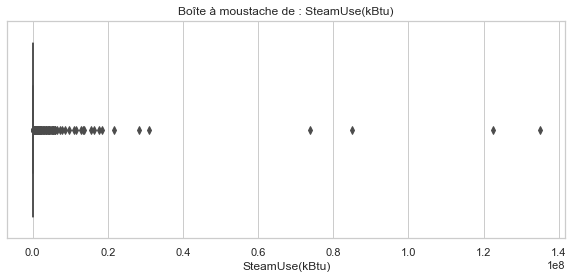

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


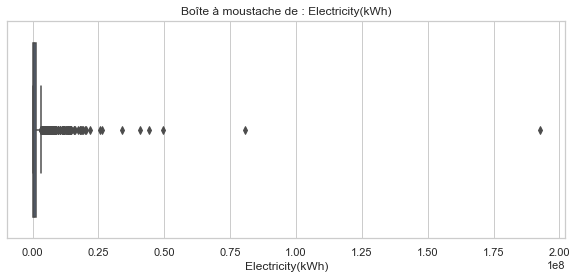

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


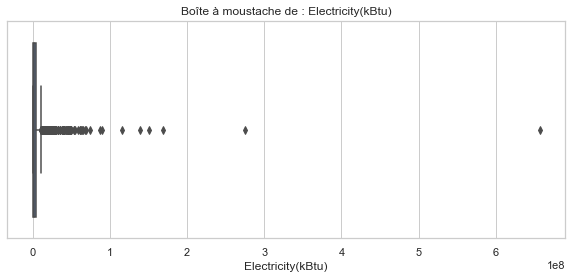

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


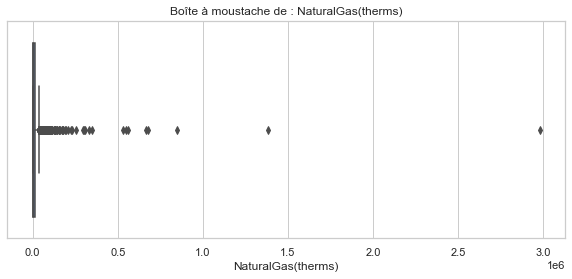

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


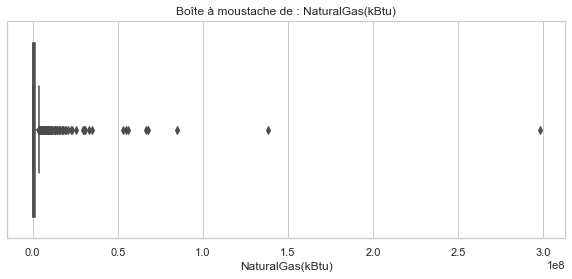

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


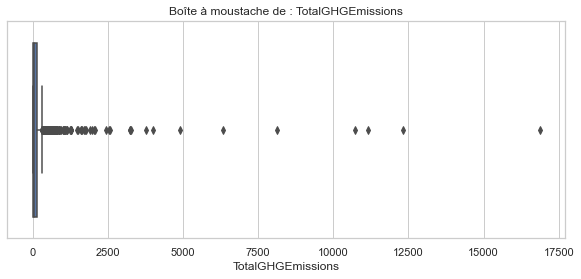

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


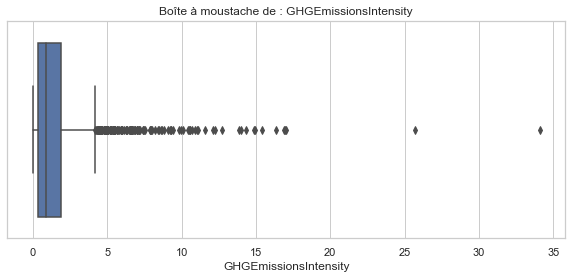

In [17]:
#visualiser outliers avec un boxplot sur les variables afin de les detecter visuellement
for col in data.select_dtypes("number"):
    plt.figure(figsize = (10,4))
    sns.boxplot(data[col])
    chaine = 'Boîte à moustache de : ' + col
    plt.title(chaine)
    plt.show()

In [18]:
#affichage des valeurs négatives des variables cibles :
outliers_neg = (data["Electricity(kBtu)"]<0) | (data["TotalGHGEmissions"]<0)

data[outliers_neg]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
3206,49784,NonResidential,Small- and Mid-Sized Office,Bullitt Center,7234600195,CENTRAL,47.61432,-122.31257,2013,1.0,6,52000,0,52000,Office,Office,48159.0,100.0,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,-0.8,-0.02


In [19]:
# on prends la valeur absolue des valeurs negatives
for column in data[["Electricity(kBtu)","TotalGHGEmissions"]]: 
    data[column] = [ abs(val) if val < 0 else val for val in data[column]]

In [20]:
from scipy.stats import zscore
# Sélection des colonnes à analyser
z_cols = ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]

# Calcul des z-scores
z_scores = data[z_cols].apply(zscore)

# Affichage des statistiques des z-scores
print(z_scores.describe())

# Affichage des valeurs extrêmes (z-score > 3 ou < -3)
outliers = (np.abs(z_scores) > 3)
print("\nNombre d'outliers par colonne :\n", outliers.sum())

       SiteEnergyUse(kBtu)  TotalGHGEmissions
count         1.666000e+03       1.666000e+03
mean          5.957619e-17       1.332801e-18
std           1.000300e+00       1.000300e+00
min          -2.790809e-01      -2.460582e-01
25%          -2.384226e-01      -2.194968e-01
50%          -1.945771e-01      -1.801054e-01
75%          -5.042496e-02      -5.665681e-02
max           2.862555e+01       2.219622e+01

Nombre d'outliers par colonne :
 SiteEnergyUse(kBtu)    11
TotalGHGEmissions      15
dtype: int64


In [21]:
z_cols = ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]
data = data[(np.abs(zscore(data[z_cols])) < 3).all(axis=1)]

In [22]:
data.NumberofFloors.sort_values(ascending=True).unique()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 33, 34, 36, 37,
       39, 41, 42, 46, 47, 49, 55, 56, 63, 76, 99], dtype=int64)

In [23]:
#Observons le type de batiment qui a la valeur 99. 
data[data.NumberofFloors == data.NumberofFloors.max()]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
1359,21611,NonResidential,Worship Facility,Seattle Chinese Baptist Church,2124049098,GREATER DUWAMISH,47.55072,-122.30265,1977,1.0,99,21948,0,21948,Worship Facility,Worship Facility,21948.0,80.0,14.9,14.9,46.599998,46.599998,326001.1875,326001.1875,0.0,95545.5,326001.0,0.0,0.0,2.27,0.1


Après vérification sur internet il se trouve que cette église a un étage, c'est donc une erreur


In [24]:
#On remplace cette variable par 1
data.NumberofFloors.replace(99,1, inplace = True)


In [25]:
print(len(data[data.NumberofFloors == data.NumberofFloors.min()]))
data[data.NumberofFloors == data.NumberofFloors.min()]

15


,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
166,267,NonResidential,Hotel,Grand Hyatt Seattle,6792120000,DOWNTOWN,47.61275,-122.33330,1999,1.0,0,934292,0,934292,"Hotel, Other, Parking, Restaurant, Retail Store",Hotel,495536.0,NaN,117.900002,120.500000,272.899994,278.200012,65047284.00,66502836.0,0.0,1.153696e+07,39364114.0,256831.625000,25683162.0,1638.46,1.75
487,656,NonResidential,Medical Office,Arnold Pavilion,8725990000,EAST,47.60979,-122.32298,2004,1.0,0,225982,0,225982,Medical Office,Medical Office,200184.0,53.0,102.699997,103.699997,246.899994,245.300003,20560622.00,20764814.0,7815663.0,3.735333e+06,12744957.0,0.000000,0.0,692.12,3.06
488,657,NonResidential,Mixed Use Property,2200 Westlake - SEDO,8729740000,DOWNTOWN,47.61783,-122.33729,2006,0.0,0,516407,0,516407,"Financial Office, Hotel, Multifamily Housing, ...",Parking,385196.0,31.0,76.300003,78.900002,199.199997,202.000000,39403320.00,40754364.0,0.0,8.626261e+06,29432803.0,99705.117190,9970512.0,734.72,1.42
564,758,NonResidential,Other,Pacific Place,6600470000,DOWNTOWN,47.61289,-122.33531,1999,1.0,0,947987,0,947987,"Office, Other - Entertainment/Public Assembly,...",Other - Mall,561684.0,NaN,62.299999,62.099998,195.600006,194.899994,46510960.00,46343304.0,0.0,1.363158e+07,46510954.0,0.000000,0.0,324.25,0.34
1754,23311,NonResidential,Medical Office,HART First Hill LLC,8590900646,EAST,47.60862,-122.32372,1945,1.0,0,274568,0,274568,"Medical Office, Parking",Medical Office,228133.0,52.0,111.000000,111.199997,235.500000,233.100006,25311526.00,25358122.0,13296249.0,3.521476e+06,12015275.0,0.000000,0.0,1110.07,4.04
1993,24086,Campus,Other,(ID#24086)Campus1:KC Metro Transit Atlantic Ce...,7666203387,GREATER DUWAMISH,47.59042,-122.32498,1991,10.0,0,230971,0,230971,"Other, Parking",Other,230970.0,NaN,91.000000,96.199997,235.100006,242.199997,21022288.00,22230844.0,0.0,4.519276e+06,15419770.0,56025.152340,5602515.0,405.05,1.75
3130,40028,NonResidential,Warehouse,Sandpoint #5,0225049077,NORTHEAST,47.68454,-122.26235,1940,1.0,0,384772,0,384772,"Non-Refrigerated Warehouse, Office",Non-Refrigerated Warehouse,349953.0,69.0,36.700001,39.000000,84.099998,86.500000,15206762.00,16139557.0,0.0,2.642108e+06,9014872.0,61918.878910,6191888.0,391.70,1.02
3131,40031,NonResidential,Medical Office,Sandpoint #25,0225049077,NORTHEAST,47.68240,-122.26223,1960,1.0,0,30287,0,30287,Medical Office,Medical Office,28050.0,32.0,78.199997,81.300003,217.399994,220.600006,2193115.00,2279632.5,0.0,5.320647e+05,1815405.0,3777.100342,377710.0,32.72,1.08
3132,40034,NonResidential,Small- and Mid-Sized Office,Sandpoint #29,0225049077,NORTHEAST,47.68254,-122.26299,1960,1.0,0,21931,0,21931,Office,Office,31845.0,32.0,124.000000,134.800003,221.899994,233.300003,3947209.25,4292216.0,0.0,4.099035e+05,1398591.0,25486.185550,2548619.0,145.11,6.62
3168,49705,Nonresidential COS,Other,Magnuson,0225049062,NORTHEAST,47.68212,-122.26330,1929,8.0,0,502030,0,502030,Other - Recreation,Other - Recreation,564258.0,NaN,32.700001,36.599998,69.000000,74.300003,18470340.00,20672948.0,0.0,2.743225e+06,9359884.0,91104.546880,9110455.0,549.11,1.09


In [26]:
floor_median = round(data.NumberofFloors.median(),2)

print(floor_median)



2.0


In [27]:
data.loc[data.NumberofFloors == data.NumberofFloors.min(),'NumberofFloors']= floor_median

# 🏛️ Traitement des variables qualitatives


In [28]:
# Regroupement de types de propriétés trop rares dans une seule catégorie "Other" pour éviter des problèmes d'overfitting (onpeut mal généraliser)
prop_type_counts = data['PrimaryPropertyType'].value_counts()
types_rare = prop_type_counts[prop_type_counts < 30].index
data['PrimaryPropertyType'] = data['PrimaryPropertyType'].replace(types_rare, 'Other')


# 📍  Analyse géographique : 


In [29]:
import plotly.express as px

fig = px.scatter_mapbox(data, lat="Latitude", lon="Longitude", hover_name="PropertyName", color = "SiteEnergyUse(kBtu)"
                       ,color_continuous_scale="viridis", zoom = 10, title= "Répartition de la consomation  en énergie des bâtiments dans la ville de Seattle" )
fig.update_layout(mapbox_style="open-street-map")
#fig.update_layout(title = "Répartition de la consomation  en énergie des bâtiments dans la ville de Seattle" )
fig.update_layout(margin={"r":0,"l":0,"b":0})
fig.show()

In [30]:
import plotly.express as px

fig = px.scatter_mapbox(data, lat="Latitude", lon="Longitude", hover_name="PropertyName", color = "TotalGHGEmissions"
                       ,color_continuous_scale="viridis", zoom = 10, title= "Répartition des émissions de co2" )
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"l":0,"b":0})
fig.show()

In [31]:
import folium
import folium.plugins

#Coordonnées du centre de Seattle
seattle_lat = 47.6062
seattle_lon = -122.3321

seattle = folium.Map(location=[seattle_lat, seattle_lon], zoom_start=11)

#Clusters
marker_cluster = folium.plugins.MarkerCluster().add_to(seattle)
for lat, lon, in zip(data.Latitude, data.Longitude):
    folium.Marker(location=[lat, lon]).add_to(marker_cluster)

seattle

# ⚖️ Feature Engineering


In [32]:
if 'YearBuilt' in data.columns:
    data['BuildingAge'] = 2016 - data['YearBuilt']
if 'NumberOfFloors' in data.columns and 'PropertyGFATotal' in data.columns:
    data['SurfaceParEtage'] = data['PropertyGFATotal'] / data['NumberOfFloors']


In [33]:
# Transformation log des cibles
#for col in ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']:
   # if col in data.columns:
       # data[f'Log_{col}'] = np.log1p(data[col])


In [34]:
data.NumberofBuildings.value_counts(ascending= False)


1.0     1552
0.0       52
2.0       14
3.0       12
5.0        8
4.0        4
6.0        2
27.0       1
11.0       1
14.0       1
23.0       1
10.0       1
8.0        1
Name: NumberofBuildings, dtype: int64

In [35]:
data[data.NumberofBuildings == 0.0].head(5)


,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,BuildingAge
63,89,NonResidential,Medical Office,Polyclinic North && South,1978201270,EAST,47.61244,-122.32140,1965,0.0,3,179014,0,179014,Medical Office,Medical Office,179014.0,48.0,93.300003,92.300003,213.399994,210.300003,16701055.00,16527711.00,0.0,2.897563e+06,9886484.0,68145.70313,6814570.0,430.84,2.41,51
76,113,NonResidential,Small- and Mid-Sized Office,KCTS9,1988200705,MAGNOLIA / QUEEN ANNE,47.62391,-122.34837,1986,0.0,2,66240,2352,63888,"Data Center, Distribution Center, Office, Park...",Office,45900.0,NaN,74.900002,75.400002,235.199997,236.600006,4166306.25,4192107.75,0.0,1.221074e+06,4166305.0,0.00000,0.0,29.04,0.44,30
160,257,NonResidential,Warehouse,Harbor Island: Warehouse E - DNRP-SWD,7666703020,GREATER DUWAMISH,47.57507,-122.35747,1916,0.0,4,79600,0,79600,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,79600.0,34.0,30.299999,30.299999,95.099998,95.099998,2411402.25,2411402.25,0.0,7.067415e+05,2411402.0,0.00000,0.0,16.81,0.21,100
201,322,NonResidential,Large Office,Cox Media Group Seattle KIRO TV (322),0656000005,DOWNTOWN,47.61757,-122.35122,1968,0.0,3,100734,26731,74003,Office,Office,100734.0,20.0,97.199997,98.199997,305.100006,308.399994,9788717.00,9892566.00,0.0,2.868908e+06,9788716.0,0.00000,0.0,68.24,0.68,48
241,366,NonResidential,Small- and Mid-Sized Office,University District Office Buiding,1142000500,NORTHEAST,47.66100,-122.31626,1961,0.0,5,99005,0,99005,Office,Office,79555.0,70.0,59.400002,63.000000,137.600006,140.699997,4728488.50,5008123.50,0.0,8.391593e+05,2863212.0,18652.76563,1865277.0,119.03,1.20,55


In [36]:
#Les batiments avec un nombre de batiments à 0 sont impossible. On replacera donc 0 par 1.
data.loc[data.NumberofBuildings == 0.0,"NumberofBuildings"] = 1 


In [37]:
data.NumberofBuildings.fillna(data.NumberofBuildings.median(), inplace = True)


# 📊  Analyse exploratoire et statistique :


C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



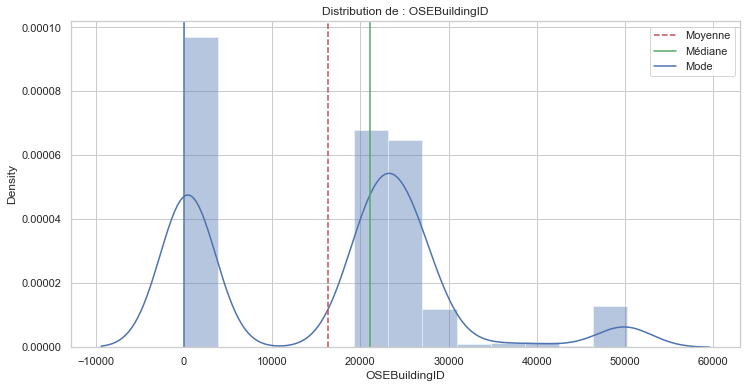

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



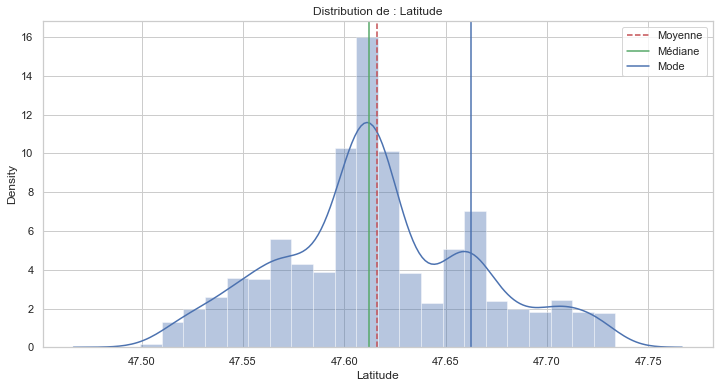

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



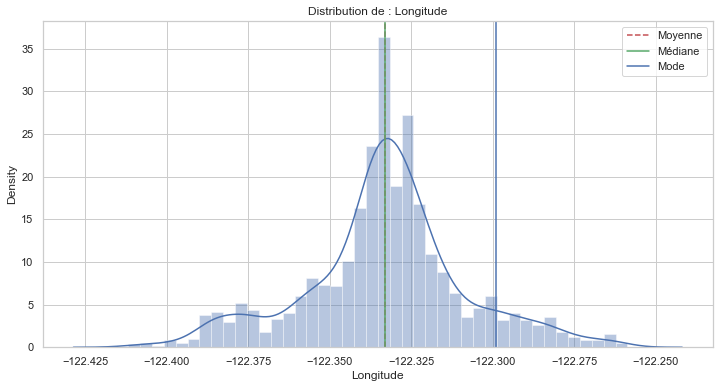

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



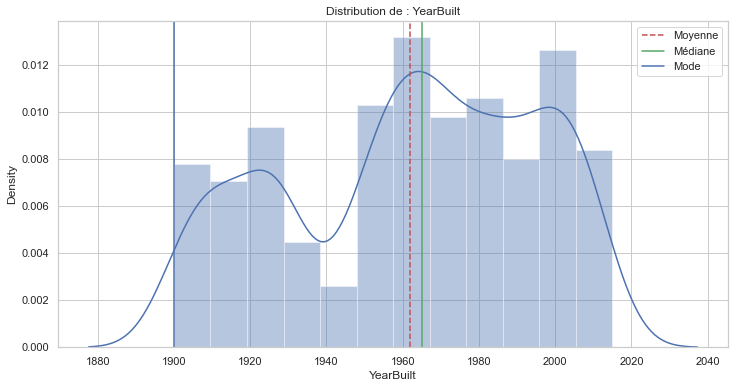

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



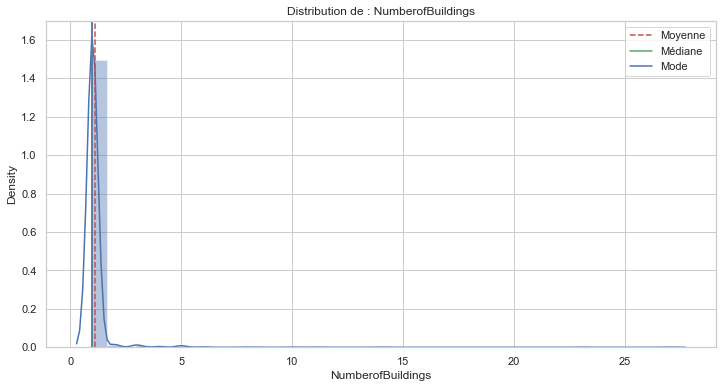

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



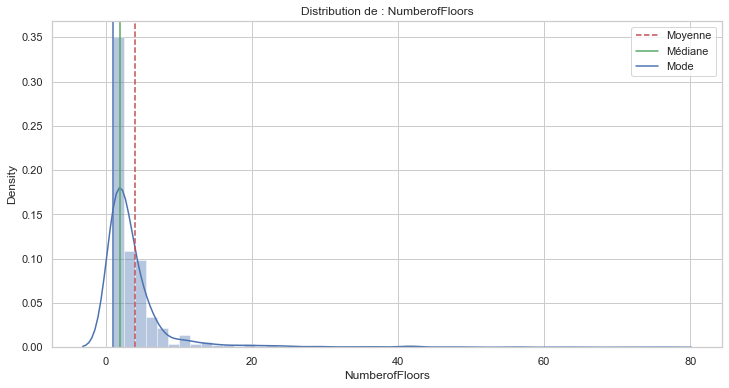

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



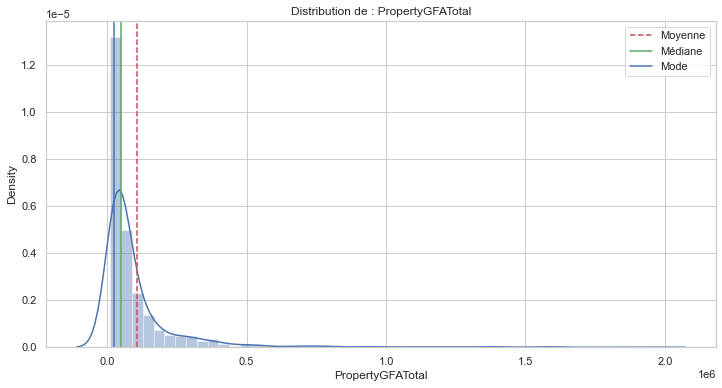

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



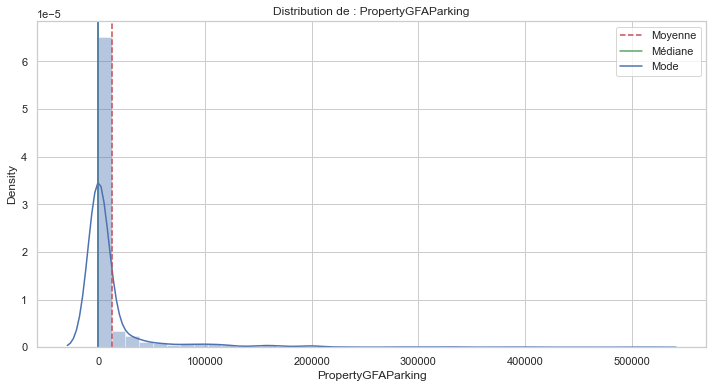

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



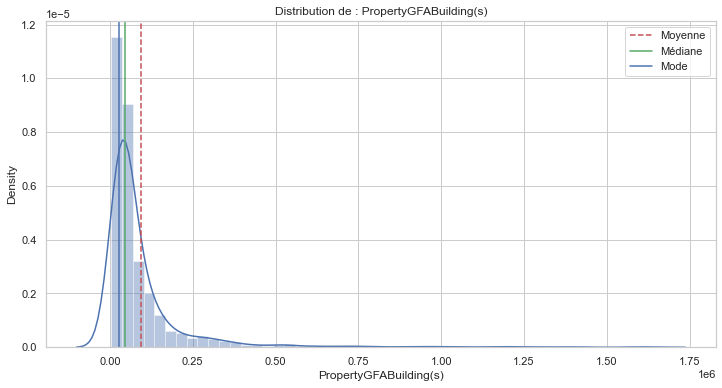

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



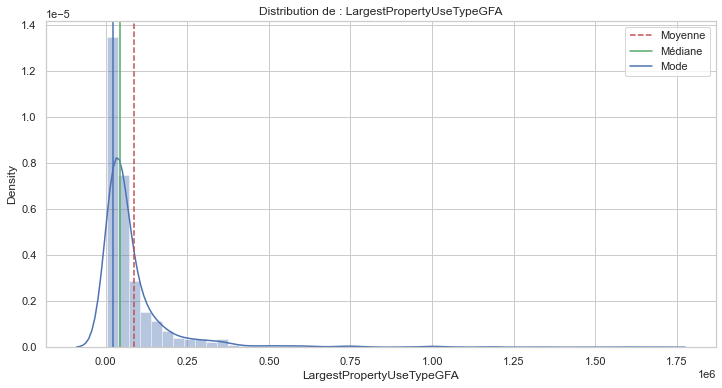

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



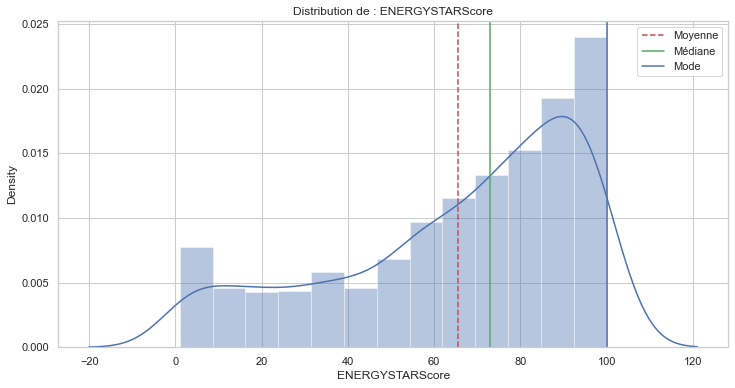

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



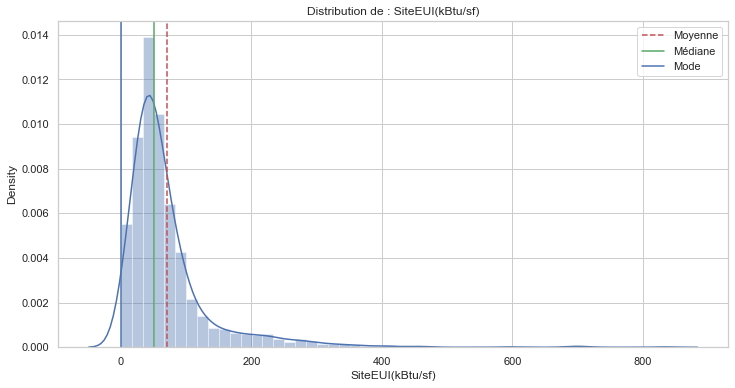

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



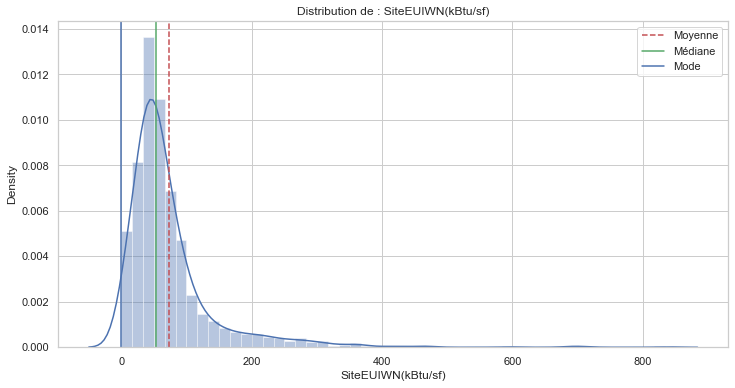

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



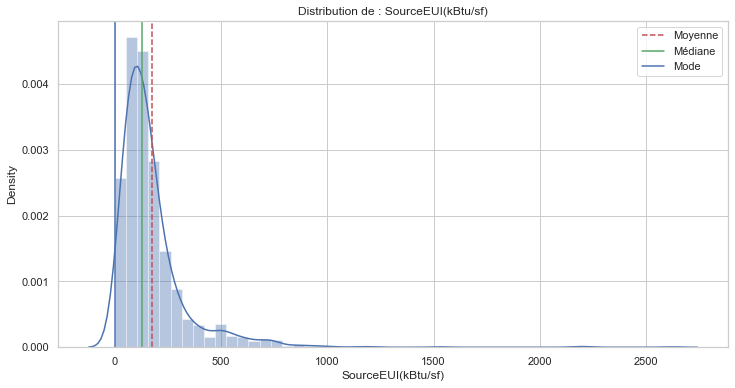

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



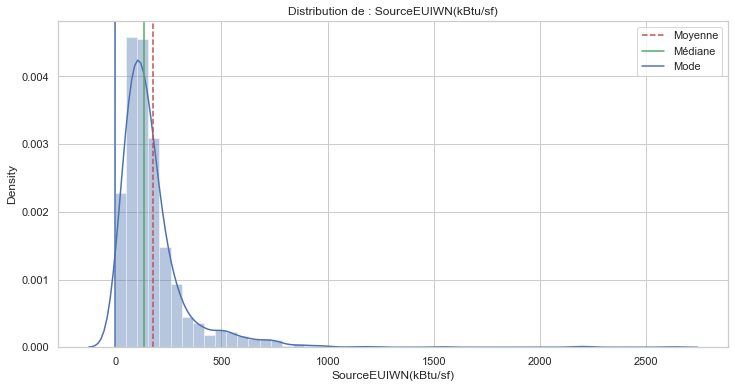

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



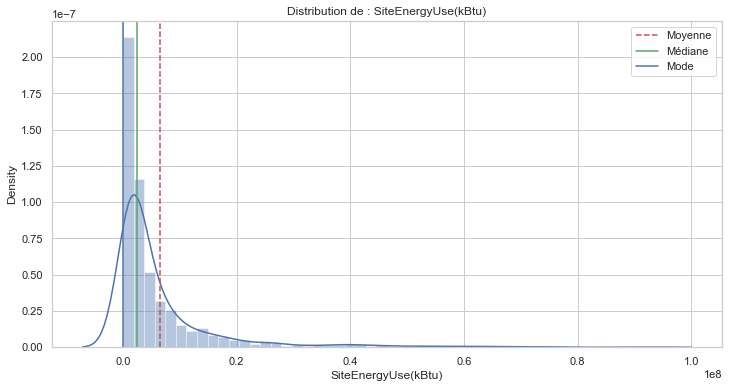

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



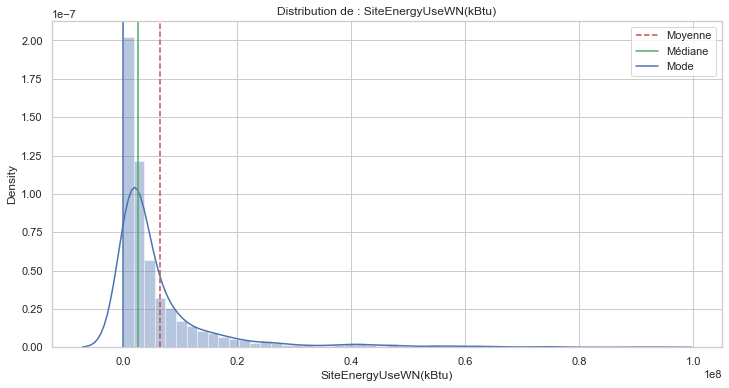

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



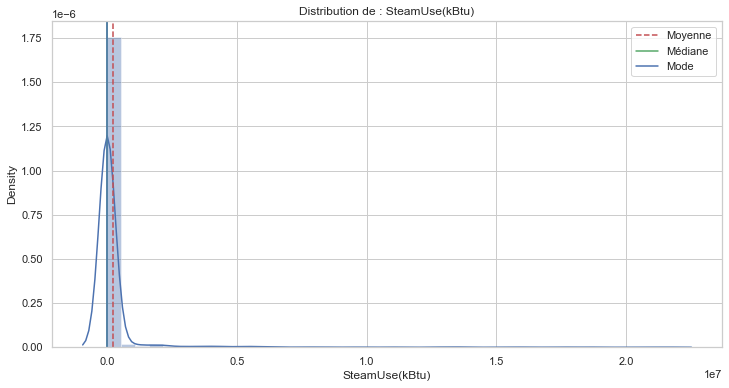

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



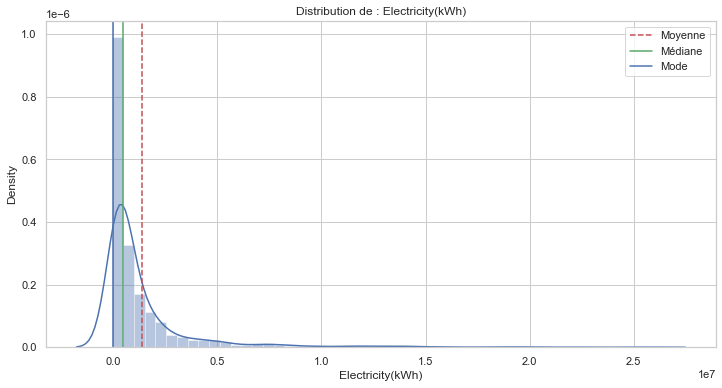

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



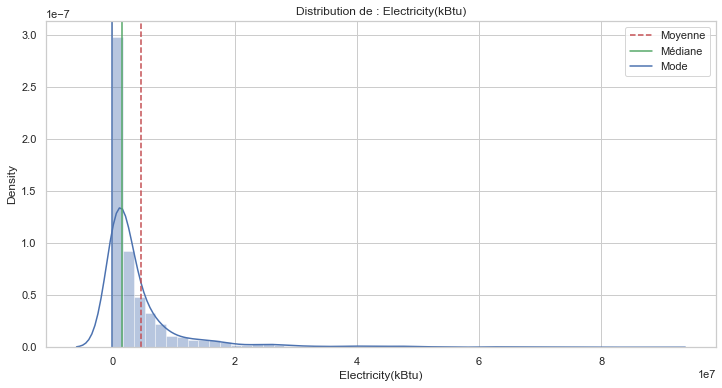

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



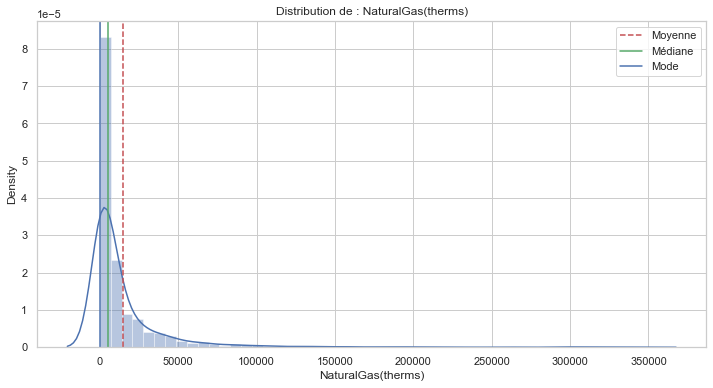

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



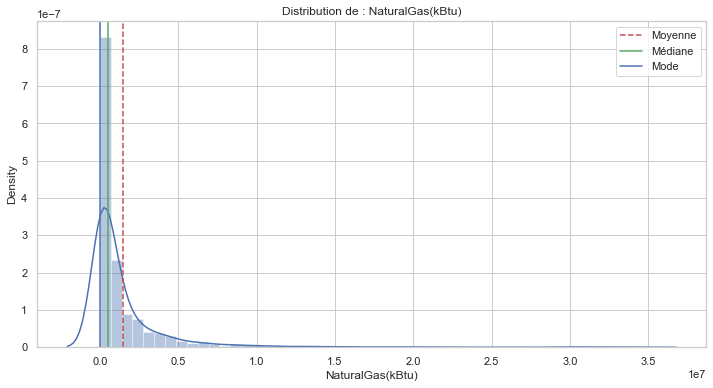

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



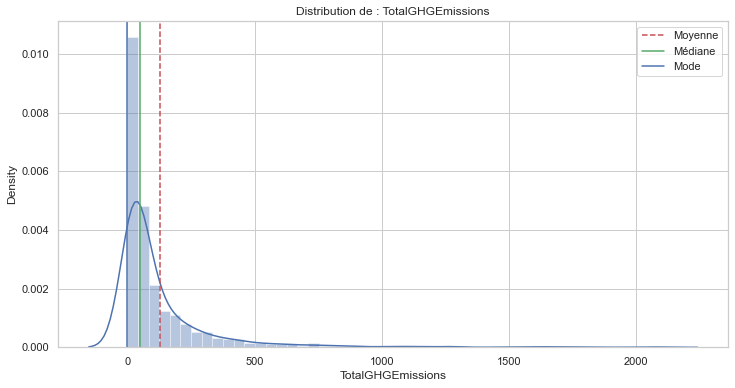

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



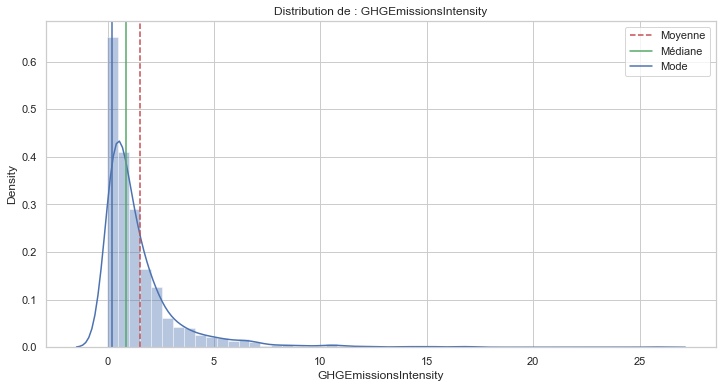

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



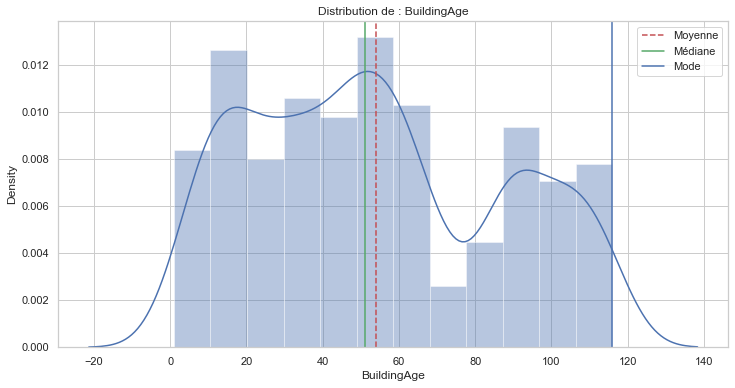

In [38]:
for col in data.select_dtypes("number"):
    plt.figure(figsize = (12,6))
    sns.distplot(data[col])
    plt.axvline(data[col].mean(), color='r', linestyle='--', label="Moyenne")
    plt.axvline(data[col].median(), color='g', linestyle='-', label="Médiane")
    plt.axvline(data[col].mode().values[0], color='b', linestyle='-', label="Mode")
    chaine = 'Distribution de : ' + col
    plt.title(chaine)
    plt.legend()
    plt.show()
    

In [39]:
 def descriptives_stat(dataframe, liste_variables):

    liste_mean = ['moyenne']
    liste_median = ['médiane']
    liste_var = ['variance']
    liste_std = ['écart-type']
    liste_skew = ["skewness : mesure d'asymétrie"]
    liste_kurtosis = ["kurtosis: mesure d'aplatissement"]
    liste_mode = ['mode']
    liste_cols = ['Desc']
    liste_max = ['max']
    liste_min = ['min']
    liste_count = ['count']

    for col in liste_variables:
        liste_mean.append(dataframe[col].mean())
        liste_median.append(dataframe[col].median())
        liste_var.append(dataframe[col].var(ddof=0))
        liste_std.append(dataframe[col].std(ddof=0))
        liste_skew.append(dataframe[col].skew())
        liste_kurtosis.append(dataframe[col].kurtosis())
        liste_cols.append(col)
        liste_mode.append(dataframe[col].mode().values[0])
        liste_min.append(dataframe[col].min())
        liste_max.append(dataframe[col].max())
        liste_count.append(dataframe[col].count())

    data_stats = [liste_count, liste_mean, liste_std, liste_median, liste_min, liste_var,  liste_skew,
                  liste_kurtosis, liste_mode, liste_max]
    df_stat = pd.DataFrame(data_stats, columns=liste_cols)
    
    return df_stat.style.hide_index()


In [40]:
descriptives_stat(data,data.select_dtypes("number"))

C:\Users\asus\AppData\Local\Temp\ipykernel_8620\1322830763.py:32: FutureWarning:

this method is deprecated in favour of `Styler.hide(axis='index')`



Desc,OSEBuildingID,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,BuildingAge
count,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1646.000000,1083.000000,1649.000000,1649.000000,1650.000000,1650.000000,1650.000000,1649.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000
moyenne,16350.966667,47.615981,-122.333008,1961.923636,1.108485,4.031515,107351.900000,12949.778788,94402.121212,86791.550425,65.597415,70.811280,73.254942,172.943394,175.343939,6415946.503544,6525667.829310,222114.502588,1376449.499176,4696585.592781,14652.042708,1465204.275174,127.703352,1.537842,54.076364
écart-type,13775.414969,0.048264,0.024630,32.741729,1.048977,6.060721,176948.895339,42343.608764,153067.056609,138322.192363,28.449182,71.982737,72.933594,179.804515,179.748510,10419874.514456,10431074.552532,1383048.375422,2522930.563471,8608162.750067,30389.166472,3038916.644239,221.442096,2.104426,32.741729
médiane,21147.500000,47.612350,-122.333000,1965.000000,1.000000,2.000000,48907.000000,0.000000,46798.500000,43268.000000,73.000000,51.500000,53.700001,130.000000,133.300003,2500610.500000,2654316.000000,0.000000,466156.656250,1590526.500000,4947.584961,494758.500000,49.175000,0.860000,51.000000
min,1.000000,47.499170,-122.411820,1900.000000,1.000000,1.000000,11285.000000,0.000000,3636.000000,5656.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000,0.000000,0.000000,-33826.800780,0.000000,0.000000,0.000000,0.000000,-0.020000,1.000000
variance,189762057.574040,0.002329,0.000607,1072.020835,1.100352,36.732340,31310911561.569580,1792981203.133371,23429523818.845890,19133028900.117443,809.355931,5181.514463,5319.309106,32329.663753,32309.526808,108573784897011.468750,108807316320481.843750,1912822808758.014893,6365178628098.281250,74100465931649.546875,923501438.888181,9235014370632.019531,49036.601751,4.428610,1072.020835
skewness : mesure d'asymétrie,0.311465,0.227613,-0.070455,-0.291915,17.280066,5.329649,4.938079,5.227257,5.123612,5.210535,-0.785011,3.780634,3.683852,4.878116,4.855877,3.496923,3.470754,9.524642,4.128210,4.128286,5.225014,5.225014,4.224902,3.868101,0.291915
kurtosis: mesure d'aplatissement,-0.397641,-0.235559,0.722946,-1.043476,362.599606,37.546298,31.794058,35.535626,33.767252,37.659861,-0.488540,23.194176,21.983315,44.517884,44.314721,14.844400,14.647322,107.217672,21.882782,21.883385,38.574296,38.574295,23.774782,23.054030,-1.043476
mode,1.000000,47.662460,-122.298980,1900.000000,1.000000,1.000000,25920.000000,0.000000,25920.000000,24000.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,116.000000
max,50226.000000,47.733870,-122.258640,2015.000000,27.000000,76.000000,1952220.000000,512608.000000,1632820.000000,1680937.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,92937640.000000,92537256.000000,21566554.000000,25747908.000000,87851862.000000,346853.312500,34685331.000000,2089.280000,25.710000,116.000000


<AxesSubplot:>

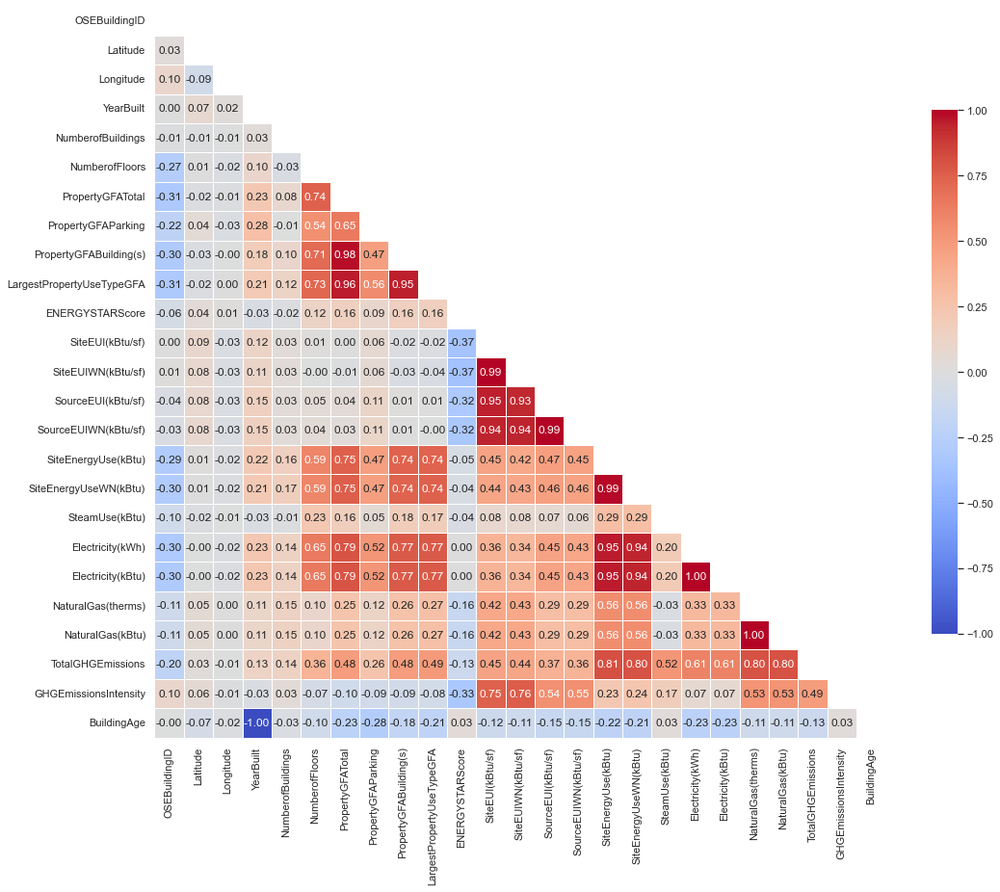

In [41]:
#Corrélations Afin de ne pas pas biaiser nos modèles de prédiction nous ne devons pas dépasser un seuil de 0.75 en corrélation de pearson entre deux variables.

corr = data.corr()
# On affiche que le triangle du bas
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(17, 20))

# Generate a custom diverging colormap
#cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap="coolwarm",annot= True, fmt = ".2f", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [42]:
#Afin de diminuer la colinéarité entre les variables de surfaces calculons les pourcentages de chaque variable en fonction de la surface totale.

data["RateParking"] = round(data.PropertyGFAParking/ data.PropertyGFATotal ,4)

data["RateBuilding"] = round(data["PropertyGFABuilding(s)"] / data["PropertyGFATotal"],4)

data["RatePerFloors"] = round(data.PropertyGFATotal/ data.NumberofFloors ,4)

data["RatePerBuildings"] = round(data.PropertyGFATotal/ data.NumberofBuildings ,4)

data["RateLargestPropertyUseType"] = round(data.LargestPropertyUseTypeGFA/ data.PropertyGFATotal ,4)




In [43]:
data["NumberOfAllUseTypes"]= data.ListOfAllPropertyUseTypes.apply(lambda row: len(row))

In [44]:
cols_to_drop = ["PropertyGFAParking", "PropertyGFABuilding(s)",
                "NumberofFloors", "NumberofBuildings",
                "LargestPropertyUseTypeGFA", "ListOfAllPropertyUseTypes"]
data.drop(columns = cols_to_drop,inplace = True)

<AxesSubplot:>

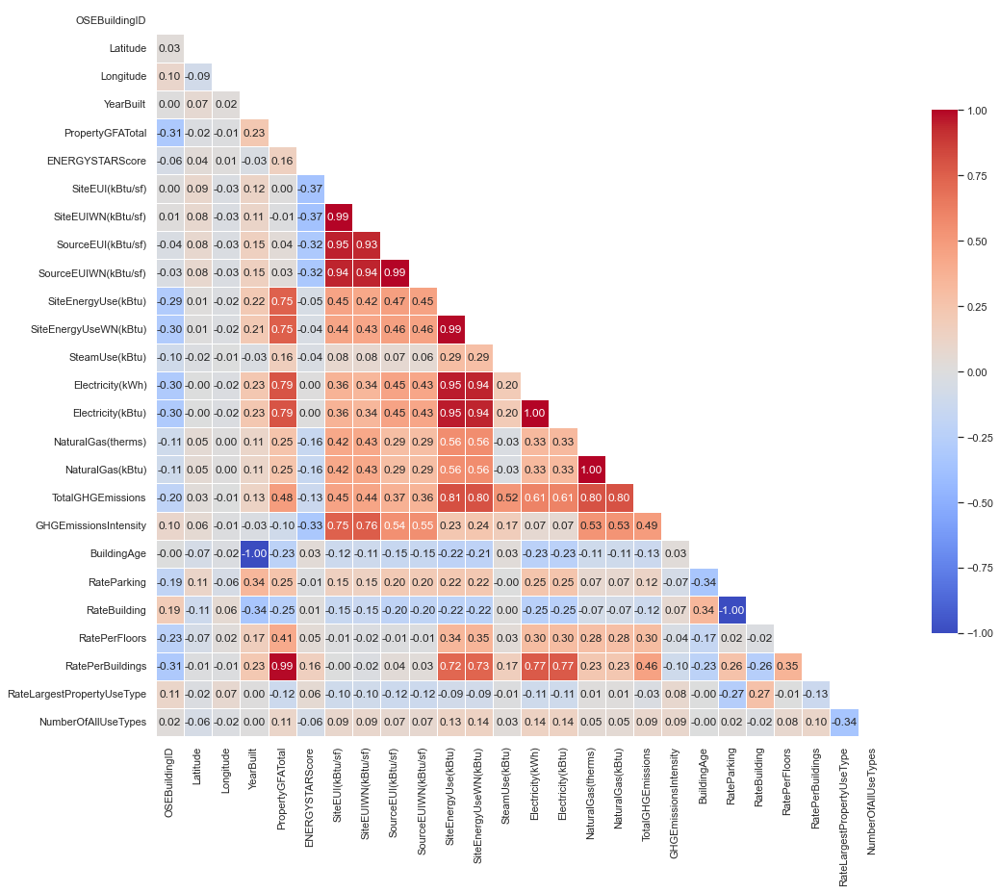

In [45]:
#Verifions l'impact de ce que nous venons d'opérer comme changements.

corr = data.corr()
# On affiche que le triangle du bas
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(17, 20))

# Generate a custom diverging colormap
#cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap="coolwarm",annot= True, fmt = ".2f", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [46]:
#SiteEUI(kBtu/sf) : Site Energy Use Intensity (EUI) is a property's Site Energy Use divided by its gross floor area.

#C'est une variable surfacique. On peut donc la supprimer car on dispose de SiteEnergyUse

#SourceEUI(kBtu/sf) : Source Energy Use Intensity (EUI) is a property's Source Energy Use divided by its gross floor area.

#C'est une variable surfacique. On peut la supprimer.

data.drop(["SourceEUI(kBtu/sf)","SiteEUI(kBtu/sf)"], axis = 1, inplace= True)



In [47]:
import time
def timeit(f):

    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print (f"Durée d'exécution de {f.__name__}: {te-ts}s")
        return result

    return timed



In [48]:
@timeit
def binarise_columns(data, col):
    idx = np.where(data[col] > 0)
    data[col].iloc[idx] = 1
    
    idx_0 = np.where(data[col] == 0)
    data[col].iloc[idx_0] = 0
    return data

In [49]:
for cols in ["Electricity(kBtu)","SteamUse(kBtu)", "NaturalGas(kBtu)"] :
    data = binarise_columns(data,cols)

C:\Users\asus\AppData\Local\Temp\ipykernel_8620\1572473323.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\asus\AppData\Local\Temp\ipykernel_8620\1572473323.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Durée d'exécution de binarise_columns: 0.2744433879852295s
Durée d'exécution de binarise_columns: 0.1688981056213379s
Durée d'exécution de binarise_columns: 0.17225933074951172s


In [50]:
data.describe()

,OSEBuildingID,Latitude,Longitude,YearBuilt,PropertyGFATotal,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,BuildingAge,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,NumberOfAllUseTypes
count,1650.000000,1650.000000,1650.000000,1650.000000,1.650000e+03,1083.000000,1649.000000,1650.000000,1.650000e+03,1.649000e+03,1650.000000,1.650000e+03,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1.650000e+03,1646.000000,1650.000000
mean,16350.966667,47.615981,-122.333008,1961.923636,1.073519e+05,65.597415,73.254942,175.343939,6.415947e+06,6.525668e+06,0.064848,1.376449e+06,0.993333,14652.042708,0.712727,127.703352,1.537842,54.076364,0.061691,0.938309,33645.913440,1.042593e+05,0.867997,24.958788
std,13779.591236,0.048279,0.024638,32.751656,1.770025e+05,28.462325,72.955718,179.803004,1.042303e+07,1.043424e+07,0.246333,2.523695e+06,0.081402,30398.379499,0.452627,221.509230,2.105064,32.751656,0.140683,0.140683,41787.689599,1.753071e+05,0.302721,20.359462
min,1.000000,47.499170,-122.411820,1900.000000,1.128500e+04,1.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000,-3.382680e+04,0.000000,0.000000,0.000000,0.000000,-0.020000,1.000000,0.000000,0.105000,3230.769200,4.300000e+03,0.186500,5.000000
25%,585.250000,47.585197,-122.343395,1930.000000,2.939250e+04,49.000000,35.299999,79.025000,1.218520e+06,1.286817e+06,0.000000,2.105215e+05,1.000000,0.000000,0.000000,19.830000,0.340000,27.000000,0.000000,1.000000,13264.625000,2.877000e+04,0.690800,12.000000
50%,21147.500000,47.612350,-122.333000,1965.000000,4.890700e+04,73.000000,53.700001,133.300003,2.500610e+06,2.654316e+06,0.000000,4.661567e+05,1.000000,4947.584961,1.000000,49.175000,0.860000,51.000000,0.000000,1.000000,22798.500000,4.748450e+04,0.963500,20.000000
75%,24601.750000,47.649645,-122.321755,1989.000000,1.029090e+05,89.000000,84.199997,203.624996,6.773662e+06,6.917478e+06,0.000000,1.372579e+06,1.000000,14700.133303,1.000000,134.660000,1.867500,86.000000,0.000000,1.000000,37793.208325,9.865950e+04,1.000000,32.000000
max,50226.000000,47.733870,-122.258640,2015.000000,1.952220e+06,100.000000,834.400024,2620.000000,9.293764e+07,9.253726e+07,1.000000,2.574791e+07,1.000000,346853.312500,1.000000,2089.280000,25.710000,116.000000,0.895000,1.000000,530039.000000,1.952220e+06,6.426800,255.000000


In [51]:
#Il ne reste qu'une variable qui présente plusieurs corrélations supérieures à 0.75 : PropertyGFATotal.

#Les infos sur la surface se retrouvent dans d'autres variables. Nous pouvons donc supprimer.

data.drop("PropertyGFATotal", axis = 1, inplace = True)

#Exploitation de la distance
Calculons la distance de Haversine par rapport au centre de Seattle.

Latitude et longitude de Seattle (WA)

Latitude de Seattle (WA): 47.6062095

Longitude de Seattle (WA): -122.3320708


In [52]:
lat_center= 47.6062
long_center= -122.3320
#La fonction haversine prends 2 tuples en entrée je crée donc des tuples de latitude et longitude
pos_center = (lat_center,long_center)

data["tuple_coord"]= data[["Latitude","Longitude"]].apply(tuple, axis = 1)

data["haversine_distance"] =[haversine((lat,lon), pos_center) for (lat, lon) in data.tuple_coord ] 

In [53]:
data.drop(columns = ["Latitude","Longitude","tuple_coord"], inplace = True)

In [54]:
# Analyse des targets

In [55]:
descriptives_stat(data,["TotalGHGEmissions","SiteEnergyUse(kBtu)"])

C:\Users\asus\AppData\Local\Temp\ipykernel_8620\1322830763.py:32: FutureWarning:

this method is deprecated in favour of `Styler.hide(axis='index')`



Desc,TotalGHGEmissions,SiteEnergyUse(kBtu)
count,1650.000000,1650.000000
moyenne,127.703352,6415946.503544
écart-type,221.442096,10419874.514456
médiane,49.175000,2500610.500000
min,0.000000,0.000000
variance,49036.601751,108573784897011.468750
skewness : mesure d'asymétrie,4.224902,3.496923
kurtosis: mesure d'aplatissement,23.774782,14.844400
mode,0.000000,0.000000
max,2089.280000,92937640.000000


In [56]:
#A l'aide de l'analyse exploratoire on peut faire l'hypothèse que les target ne suivent pas de loi normale. Confirmons la avec un test de normalité.
from scipy.stats import normaltest

for x in ["TotalGHGEmissions","SiteEnergyUse(kBtu)"]:
    k2,p = normaltest(data[x])
    print(f"test de normalité de {x}, p = {p}")
    print("-"*70)
    alpha = 1e-3
    if p < alpha:  #  hypothèse nulle: x est une distribution normale
        print(f"L'hypothèse nulle sur {x} peut être rejetée")
        print("-"*70)
    else:
        print(f"L'hypothèse nulle sur {x} peut être rejetée")

test de normalité de TotalGHGEmissions, p = 0.0
----------------------------------------------------------------------
L'hypothèse nulle sur TotalGHGEmissions peut être rejetée
----------------------------------------------------------------------
test de normalité de SiteEnergyUse(kBtu), p = 4.012341826218076e-269
----------------------------------------------------------------------
L'hypothèse nulle sur SiteEnergyUse(kBtu) peut être rejetée
----------------------------------------------------------------------


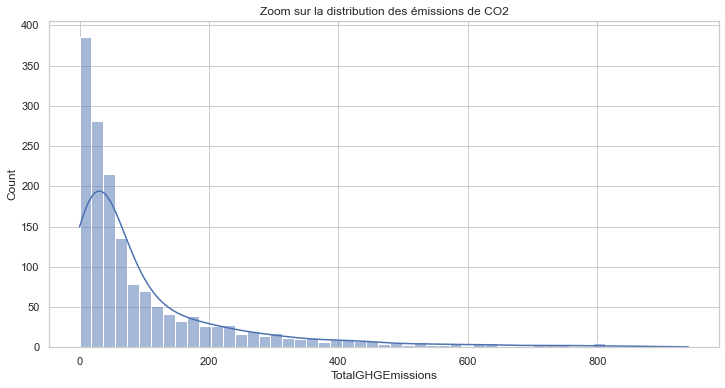

In [57]:
plt.figure(figsize = (12,6))
sns.histplot(data=data[(data['TotalGHGEmissions']< 1000)], x="TotalGHGEmissions", kde=True)
plt.title("Zoom sur la distribution des émissions de CO2")
plt.show()

In [58]:
#On observe une forte asymétrie à droite on dois donc la transformer pour se rapprocher d'une distribution normale.


In [59]:
test1 = np.log1p(data['TotalGHGEmissions'])
test2 = np.log2(1+data['TotalGHGEmissions'])
test10 = np.log10(1+data['TotalGHGEmissions'])

#test_log = pd.DataFrame( {'test1': test1, 'test2': test2, 'test10': test10})

In [60]:
print("Variance avec log1p : ",test1.var())
print("Variance avec log2p :", test2.var())
print("Variance avec log10p :", test10.var())

Variance avec log1p :  1.9742096804794134
Variance avec log2p : 4.10905879095083
Variance avec log10p : 0.3723590380919783


In [61]:
import plotly.figure_factory as ff

hist_data = [test1, test2, test10]

group_labels = ['log1p', 'log2p', 'log10p']


fig = ff.create_distplot(hist_data, group_labels, bin_size=0.15)

fig.update_layout(title_text='Impact des différentes transformations logarithmiques sur la distribution des émissions de CO2 ',
                  width=800,height=900)
fig.show()

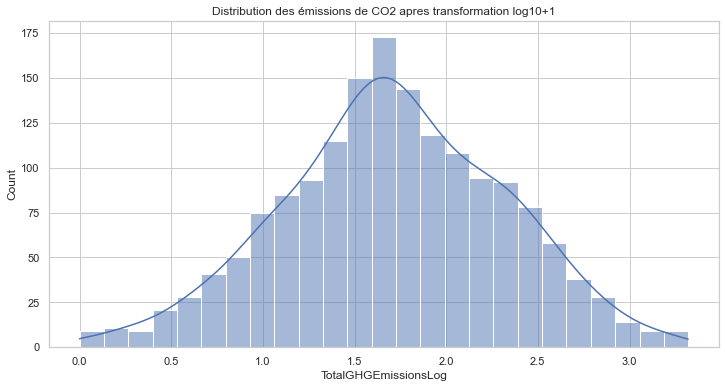

In [62]:
#On choisi la transformation qui donne la plus faible variance donc log10 + 1.

data["TotalGHGEmissionsLog"]= np.log10(1+data["TotalGHGEmissions"])

plt.figure(figsize = (12,6))
sns.histplot(data=data, x="TotalGHGEmissionsLog", kde=True)
plt.title("Distribution des émissions de CO2 apres transformation log10+1")
plt.show()


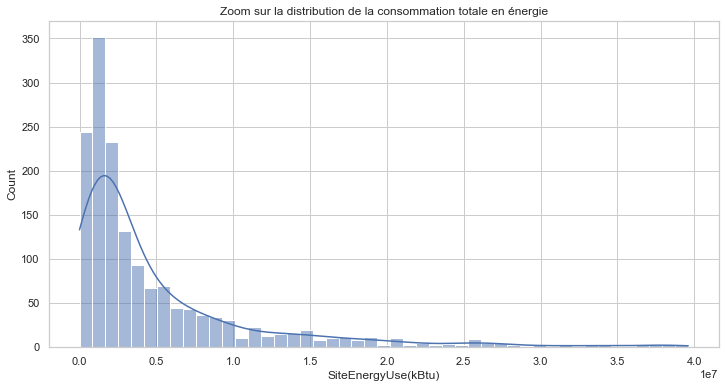

In [63]:
plt.figure(figsize = (12,6))
sns.histplot(data= data[data["SiteEnergyUse(kBtu)"]<0.4*10**8 ], x = "SiteEnergyUse(kBtu)", kde=True )
plt.title("Zoom sur la distribution de la consommation totale en énergie")
plt.show()

In [64]:
SEUtest1 = np.log1p(data['SiteEnergyUse(kBtu)'])
SEUtest2 = np.log2(1 + data['SiteEnergyUse(kBtu)'])
SEUtest10 = np.log10(1 + data['SiteEnergyUse(kBtu)'])


In [65]:
print("Variance avec log1p : ",SEUtest1.var())
print("Variance avec log2p :", SEUtest2.var())
print("Variance avec log10p :", SEUtest10.var())

Variance avec log1p :  3.7190023135103125
Variance avec log2p : 7.740616055628428
Variance avec log10p : 0.7014473375412978


In [66]:
hist_data = [SEUtest1, SEUtest2, SEUtest10]

group_labels = ['log1p', 'log2p', 'log10p']


fig = ff.create_distplot(hist_data, group_labels, bin_size=0.15)

fig.update_layout(title_text='Transformations logarithmiques sur la distribution de la consommation totale en énergie',
                  width=800,height=900)
fig.show()

In [67]:
data["SiteEnergyUse(kBtu)Log"]= np.log10(1+data["SiteEnergyUse(kBtu)"])

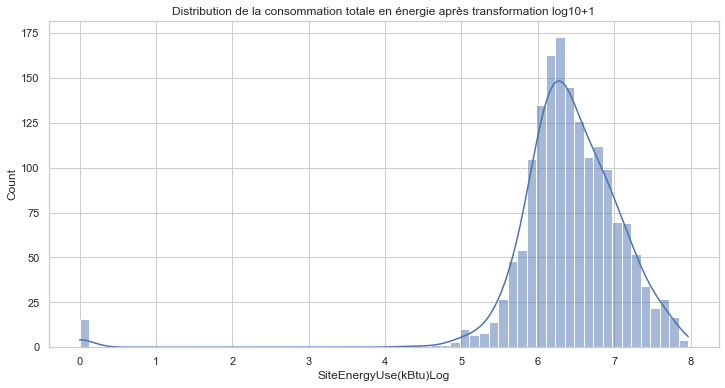

In [68]:
plt.figure(figsize = (12,6))
sns.histplot(data=data, x="SiteEnergyUse(kBtu)Log", kde=True)
plt.title("Distribution de la consommation totale en énergie après transformation log10+1")
plt.show()

In [69]:
fig = px.scatter(data,
                 x="TotalGHGEmissionsLog",
                 y="SiteEnergyUse(kBtu)Log",
                 title = "Répartition des émissions de CO2 en fonction de la consommation totale en énergie",
                 color = "SiteEnergyUse(kBtu)Log",
                color_continuous_scale=px.colors.sequential.Cividis_r)
fig.show()

In [70]:
fig = px.scatter(data,
                 y="TotalGHGEmissionsLog",
                 x="SiteEnergyUse(kBtu)Log",
                 title = "Répartition de la consommation totale en énergie en fonction des émissions de CO2",
                 color = "SiteEnergyUse(kBtu)Log",
                color_continuous_scale=px.colors.sequential.Viridis)
fig.show()

On peut constater que les émissions de CO2 augmentent avec la consommation en énergie comme on pouvait le deviner.


In [71]:
# Analyse multivariée


In [72]:
#Est-ce que la position des bâtiments influe sur leur consommation en énergie?

fig = px.scatter(data, x= "haversine_distance", y = "TotalGHGEmissionsLog",
                 color= "TotalGHGEmissionsLog", 
                title = "Repartition des émissions de Co2 en fonction de la distance .")
fig.show()

Les coordonnées géographiques ont une influence sur les émissions de Co2 et donc la consommation en énergie.



In [73]:
fig = px.scatter(data, y= "RatePerBuildings", x = "SiteEnergyUse(kBtu)Log",
                 color= "SiteEnergyUse(kBtu)Log", 
                title = "Consommation totale en énergie en fonction de la surface des bâtiments de la propriété .")
fig.show()

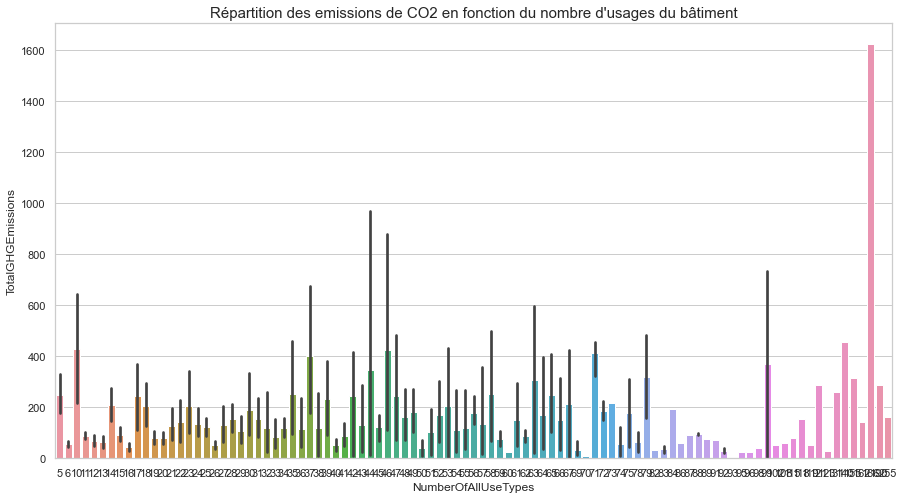

In [74]:
plt.figure(figsize=(15,8))
sns.barplot(x = "NumberOfAllUseTypes", y= "TotalGHGEmissions", data=data)
plt.title("Répartition des emissions de CO2 en fonction du nombre d'usages du bâtiment", fontsize=15)
plt.show()

C:\Users\asus\.InstallAnywhere\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



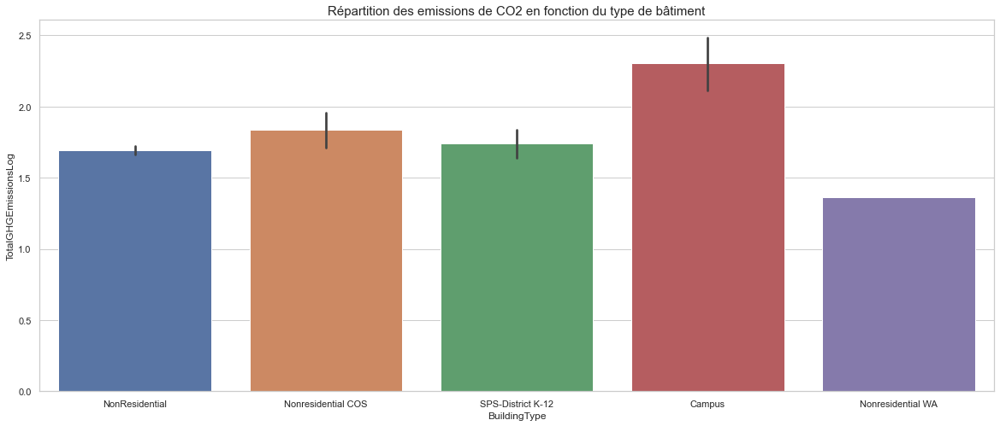

In [75]:
plt.figure(figsize=(20,8))
sns.barplot("BuildingType", y= "TotalGHGEmissionsLog", data=data)
plt.title("Répartition des emissions de CO2 en fonction du type de bâtiment", fontsize=15)
plt.show()

Les campus sont les plus énergivores



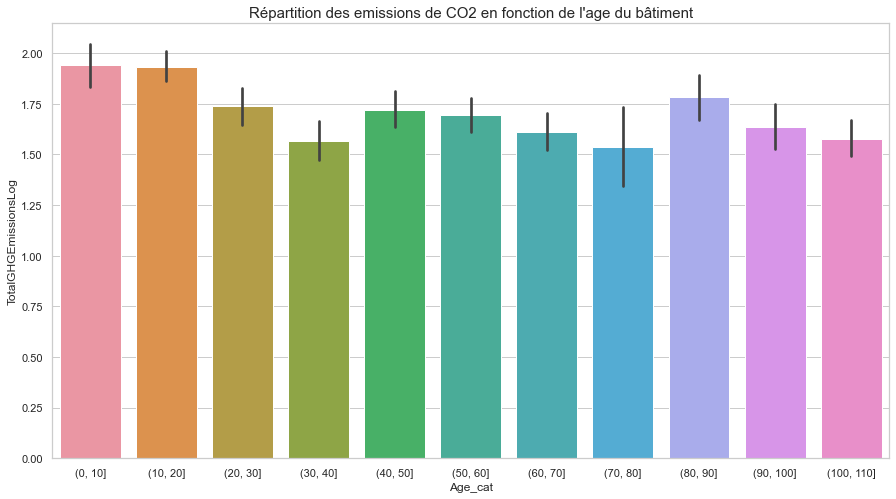

In [76]:
data['Age_cat'] = pd.cut(data['BuildingAge'], 
    bins=[x for x in range(0,120, 10)], 
    right=True)
plt.figure(figsize=(15,8))
sns.barplot(x = "Age_cat", y= "TotalGHGEmissionsLog", data=data)
plt.title("Répartition des emissions de CO2 en fonction de l'age du bâtiment", fontsize=15)
plt.show()

Certains ages de bâtiments ont de plus forts rejets de Co2. Notemment la tranche 70-80.



In [78]:
data.drop("Age_cat", axis=1, inplace = True)


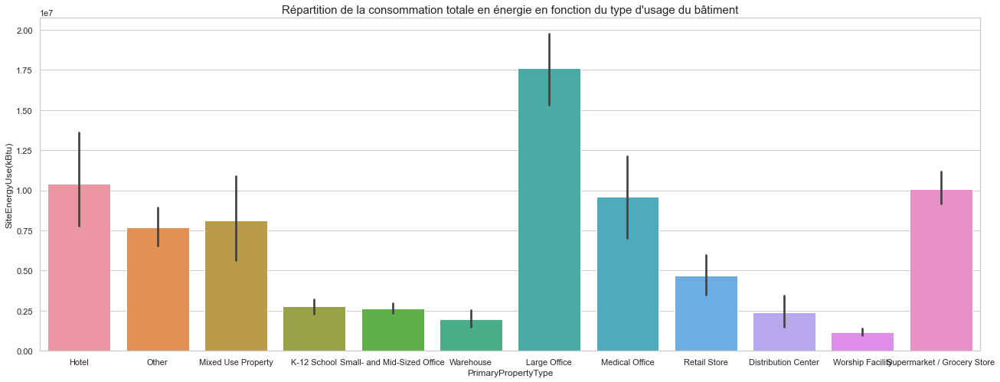

In [79]:
plt.figure(figsize=(22,8))
sns.barplot(x = "PrimaryPropertyType", y= "SiteEnergyUse(kBtu)", data=data)
plt.title("Répartition de la consommation totale en énergie en fonction du type d'usage du bâtiment", fontsize=15)
plt.show()


Comme on pouvait le deviner, les universités et les hopitaux ou bâtiment à usage pour la santé consomment le plus.



In [80]:
fig = px.scatter(data, x= "RateLargestPropertyUseType", y = "SiteEnergyUse(kBtu)Log",
                 color= "SiteEnergyUse(kBtu)Log", 
                title = "Consommation totale en fonction de la surface du plus grand type d'usage des bâtiments.")
fig.show()

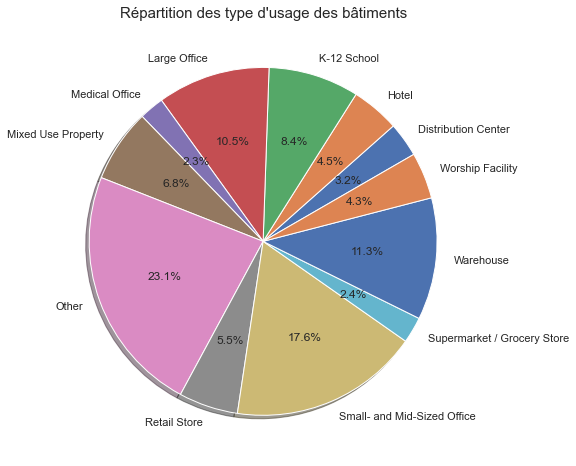

In [81]:
primaryType = data.groupby(by='PrimaryPropertyType')['PropertyName'].nunique()
plt.figure(figsize=(22,8))
plt.pie(primaryType.values, labels = primaryType.index,
        autopct='%1.1f%%', shadow=True, startangle=30)
plt.title("Répartition des type d'usage des bâtiments", fontsize=15)
plt.show()

In [82]:
data.drop(columns=["SiteEnergyUse(kBtu)", "TotalGHGEmissions"], inplace = True)


# 💾 Export du jeu de données nettoyé


In [83]:
data.reset_index(drop = True, inplace =True)


In [84]:
data.to_csv("donnees_nettoyees.csv", index=False)
print("Fichier nettoyé sauvegardé sous 'donnees_nettoyees.csv'")


Fichier nettoyé sauvegardé sous 'donnees_nettoyees.csv'


In [85]:
df=data = pd.read_csv('donnees_nettoyees.csv')

In [86]:
df.head(10)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Neighborhood,YearBuilt,LargestPropertyUseType,ENERGYSTARScore,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,BuildingAge,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,NumberOfAllUseTypes,haversine_distance,TotalGHGEmissionsLog,SiteEnergyUse(kBtu)Log
0,1,NonResidential,Hotel,Mayflower park hotel,0659000030,DOWNTOWN,1927,Hotel,60.0,84.300003,189.000000,7456910.0,1.0,1.156514e+06,1.0,12764.529300,1.0,2.83,89,0.0000,1.0000,7369.5000,88434.0,1.0000,5,0.804213,2.399639,6.858920
1,2,NonResidential,Hotel,Paramount Hotel,0659000220,DOWNTOWN,1996,Hotel,61.0,97.900002,179.399994,8664479.0,0.0,9.504252e+05,1.0,51450.816410,1.0,2.86,20,0.1455,0.8545,9415.0909,103566.0,0.8099,26,0.788419,2.472552,6.923655
2,3,NonResidential,Hotel,5673-The Westin Seattle,0659000475,DOWNTOWN,1969,Hotel,43.0,97.699997,244.100006,73937112.0,1.0,1.451544e+07,1.0,14938.000000,1.0,2.19,47,0.2057,0.7943,23319.7561,956110.0,0.7912,5,0.973609,3.320204,7.860859
3,5,NonResidential,Hotel,HOTEL MAX,0659000640,DOWNTOWN,1926,Hotel,56.0,113.300003,224.000000,6946800.5,1.0,8.115253e+05,1.0,18112.130860,1.0,4.67,90,0.0000,1.0000,6132.0000,61320.0,1.0000,5,0.946869,2.458532,6.832163
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),0659000970,DOWNTOWN,1980,Hotel,75.0,118.699997,215.600006,14656503.0,0.0,1.573449e+06,1.0,88039.984380,1.0,2.88,36,0.3531,0.6469,9754.4444,175580.0,0.7031,29,1.052598,2.704159,7.151450
5,9,Nonresidential COS,Other,West Precinct,0660000560,DOWNTOWN,1999,Police Station,NaN,141.600006,320.500000,12581712.0,0.0,2.160444e+06,1.0,47151.816410,1.0,3.10,17,0.3823,0.6177,48644.0000,97288.0,0.9131,14,1.166716,2.481170,7.082305
6,10,NonResidential,Hotel,Camlin,0660000825,DOWNTOWN,1926,Hotel,27.0,74.500000,154.699997,6062767.5,0.0,8.239199e+05,1.0,29475.800780,1.0,2.12,90,0.0000,1.0000,7546.1818,83008.0,0.9801,5,0.858460,2.248317,6.760332
7,11,NonResidential,Other,Paramount Theatre,0660000955,DOWNTOWN,1926,Other - Entertainment/Public Assembly,NaN,68.800003,152.300003,7067881.5,1.0,1.065843e+06,1.0,3851.890137,1.0,2.16,90,0.0000,1.0000,12845.1250,102761.0,1.0000,37,0.787612,2.347350,6.799212
8,12,NonResidential,Hotel,311wh-Pioneer Square,0939000080,DOWNTOWN,1904,Hotel,43.0,86.599998,187.199997,14194054.0,0.0,2.138898e+06,1.0,64259.000000,1.0,2.39,112,0.0000,1.0000,10932.2667,163984.0,1.0000,5,0.365560,2.594569,7.137475
9,15,NonResidential,Hotel,Hotel Monaco Seattle,0942000145,DOWNTOWN,1969,Hotel,30.0,124.300003,233.000000,16646930.0,1.0,1.813490e+06,1.0,45918.500000,1.0,4.51,47,0.1259,0.8741,13923.9091,153163.0,0.8741,5,0.180816,2.840269,7.204572
